In [14]:
from db_connector import list_all_tables, load_table_to_df
import pandas as pd
import numpy as np
import random
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

# 1. 데이터 로드
all_tables = list_all_tables()
required_tables = ['user_profiles', 'meal_candidates', 'meal_candidate_items', 'foods', 'recommendation_runs', 'recommendation_candidates']
all_dfs = {table: load_table_to_df(table) for table in all_tables if table in required_tables}
print("학습에 필요한 데이터 로드 완료!")

학습에 필요한 데이터 로드 완료!


In [24]:
# 1. 데이터 전처리 및 피처 엔지니어링
def build_xgboost_dataset(all_dfs):
    profiles = all_dfs['user_profiles']
    candidates = all_dfs['meal_candidates']
    cand_items = all_dfs['meal_candidate_items']
    foods = all_dfs['foods']
    rec_cands = all_dfs.get('recommendation_candidates', pd.DataFrame())
    rec_runs = all_dfs.get('recommendation_runs', pd.DataFrame())

    # 1.1 Positive Samples (Label=1)
    if not rec_runs.empty and not rec_cands.empty:
        rc_full = rec_cands.merge(rec_runs[['run_id', 'user_id']], on='run_id', how='left')
    else:
        rc_full = pd.DataFrame(columns=['user_id', 'candidate_id', 'was_selected', 'lightfm_score'])

    pos_data = rc_full[rc_full['was_selected'] == True].copy()
    pos_data['label'] = 1
    
    # lightfm_score의 평균값 계산 (결측치 채우기용)
    lightfm_mean = rc_full['lightfm_score'].mean() if not rc_full['lightfm_score'].isna().all() else 0.5
    if pd.isna(lightfm_mean):
        lightfm_mean = 0.5

    # 1.2 Negative Samples (Label=0) 생성 (Negative Sampling)
    neg_samples = []
    all_cand_ids = candidates['candidate_id'].unique()
    for user_id in pos_data['user_id'].unique():
        user_pos_cands = pos_data[pos_data['user_id'] == user_id]['candidate_id'].unique()
        possible_negs = list(set(all_cand_ids) - set(user_pos_cands))
        
        # 1:3 비율로 Negative 샘플링
        num_pos = len(pos_data[pos_data['user_id'] == user_id])
        num_neg = min(len(possible_negs), num_pos * 3)
        
        if possible_negs:
            selected_negs = random.sample(possible_negs, num_neg)
            for c_id in selected_negs:
                neg_samples.append({'user_id': user_id, 'candidate_id': c_id, 'label': 0, 'lightfm_score': lightfm_mean})
                
    neg_df = pd.DataFrame(neg_samples)
    
    if 'lightfm_score' not in pos_data.columns:
        pos_data['lightfm_score'] = np.nan
        
    full_df = pd.concat([pos_data[['user_id', 'candidate_id', 'label', 'lightfm_score']], neg_df], ignore_index=True)

    # lightfm_score 결측치 처리 (0.5 대신 평균값으로 채움)
    full_df['lightfm_score'] = full_df['lightfm_score'].fillna(lightfm_mean)

    # 1.3 피처 결합 (User, Meal, Food Stats)
    # 유저 특징
    profiles['goal_type_enc'] = profiles['goal_type'].map({'diet': 0, 'bulk': 1, 'maintain': 2}).fillna(-1)
    profiles['sex_enc'] = profiles['sex'].map({'M': 0, 'F': 1}).fillna(-1)
    full_df = full_df.merge(profiles[['user_id', 'age_years_snapshot', 'activity_factor', 'goal_type_enc', 'sex_enc']], on='user_id', how='left')

    # 식단 특징
    full_df = full_df.merge(candidates[['candidate_id', 'total_price_krw', 'total_calories_kcal', 'total_protein_g', 'total_fat_g', 'total_carbs_g']], on='candidate_id', how='left')

    # 식단 내 특정 식품군 포함 개수 계산
    food_stats = cand_items.merge(foods[['food_id', 'is_low_fat', 'is_high_protein']], on='food_id')
    meal_stats = food_stats.groupby('candidate_id').agg({'is_low_fat': 'sum', 'is_high_protein': 'sum'}).reset_index()
    meal_stats.columns = ['candidate_id', 'count_low_fat', 'count_high_protein']
    
    full_df = full_df.merge(meal_stats, on='candidate_id', how='left').fillna(0)

    feature_cols = ['age_years_snapshot', 'activity_factor', 'goal_type_enc', 'sex_enc', 
                    'total_price_krw', 'total_calories_kcal', 'total_protein_g', 'total_fat_g', 'total_carbs_g',
                    'count_low_fat', 'count_high_protein']
    
    return full_df[feature_cols], full_df['label'], feature_cols

X, y, features = build_xgboost_dataset(all_dfs)
print(f"데이터셋 구축 완료: {X.shape[0]} rows, {len(features)} features")

데이터셋 구축 완료: 1225 rows, 11 features


In [25]:
# 2. 모델 학습 (9:1 Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss'
)

print("XGBoost 모델 학습 중...")
model.fit(X_train, y_train)
print("학습 완료!")

XGBoost 모델 학습 중...
학습 완료!



[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.74      0.85        39
           1       0.89      1.00      0.94        84

    accuracy                           0.92       123
   macro avg       0.95      0.87      0.90       123
weighted avg       0.93      0.92      0.92       123

ROC-AUC Score: 0.9020


<Figure size 1000x600 with 0 Axes>

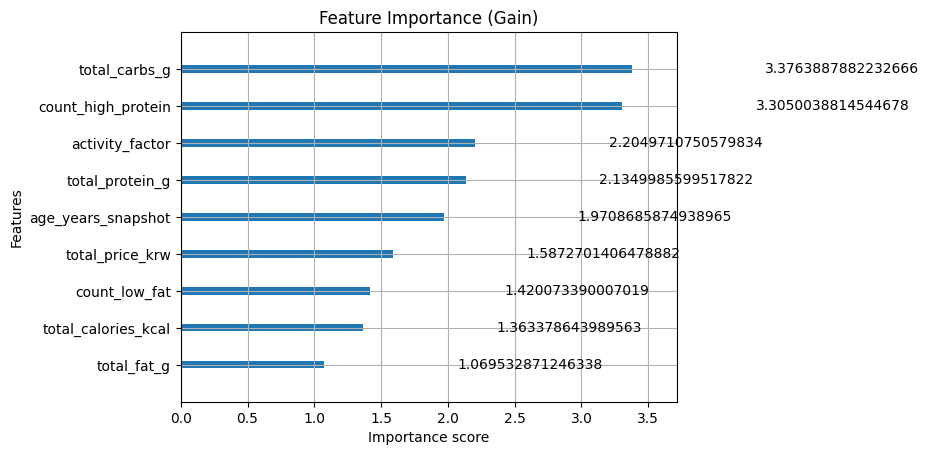

In [26]:
# 3. 모델 평가
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n[Classification Report]")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 피처 중요도 시각화
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Feature Importance (Gain)")
plt.show()